## 01. 차원축소

### 01-01. 차원의 저주

![https://datapedia.tistory.com/15](https://d.pr/i/knryou+)

차원이란 입력 데이터의 feature를 의미한다.
시각화를 진행하면 각 feature가 하나의 축으로 지정되고 지정된 수 만큼 차원이 증가한다.

이때, 차원이 많아질수록 자주 언급되는 문제가 **차원의 저주(Curse of Dimensionality)** 이다.

- feature가 많아지면 같은 데이터 개수라도 고차원 공간에서는 데이터가 드문드문 퍼진 것처럼 보일 수 있다.
- 그러면 가까운 데이터를 찾기 어렵고, 거리 기반 모델에서는 거리 계산의 의미가 약해질 수 있다.

- 단, feature가 많다고 항상 문제가 생기는 것은 아니다.
    - 데이터 수가 충분히 많고 의미 있는 feature라면 도움이 될 수 있음.
    - 문제는 관측치 수에 비해 feature가 너무 많거나, 노이즈 feature가 많을 때 자주 나타남.

---

### 01-02. 차원축소란?

차원축소는 많은 feature를 더 적은 수의 feature 또는 새 축으로 줄이는 과정이다.
목표는 feature 수를 줄이면서도 데이터의 중요한 패턴은 최대한 유지하는 것이다.

**차원축소 장점**


**1. 시각화가 쉬워짐**
- feature가 4개, 10개, 100개이면 사람이 한 번에 그래프로 보기 어려움.
- 2차원으로 줄이면 산점도로 데이터 분포, class 분리, 군집 구조를 확인할 수 있음.

**2. 계산량을 줄일 수 있음**
- feature 수가 많으면 모델이 계산해야 할 값도 많아짐.
- 특히 거리 기반 알고리즘인 KNN, SVM, KMeans는 feature 수와 스케일의 영향을 많이 받음.

**3. 노이즈 영향을 줄일 수 있음**
- 모든 feature가 예측이나 구조 파악에 도움이 되는 것은 아님.
- 덜 중요한 변동을 줄이고 큰 구조를 남기면 데이터가 더 깔끔하게 보일 수 있음.

**4. 고차원 데이터의 구조를 이해할 수 있음**
- 이미지, 텍스트, 고객 행동 데이터처럼 feature가 많은 데이터는 원본 그대로 해석하기 어려움.
- 차원축소를 사용하면 데이터가 어떤 방향으로 퍼져 있는지, 비슷한 샘플끼리 모이는지 확인할 수 있음.


---

### 01-03. 차원축소 방법

![](https://d.pr/i/QSgF7J+)


**Feature Extraction, 특성 추출**
- 기존 feature들을 조합해 새로운 feature를 만듦.
- PCA와 LDA는 이 방식에 가까움.
- 예: 원본 4개 feature를 조합해 `PC1`, `PC2`라는 새 축을 만듦.
- 정보는 압축되지만 새 축의 의미를 원본 feature처럼 바로 해석하기는 어려움.


**Feature Selection, 특성 선택**
- 기존 feature 중 중요한 feature만 고름.
- 예: `age`, `income`, `purchase_count` 중 의미 있는 컬럼만 선택함.
- 원본 컬럼 이름이 유지되어 해석이 쉬움.

---

### 01-04. 주의할 점

- 차원축소는 정보를 줄이는 과정이므로 정보 손실이 생길 수 있음.
- 차원을 줄였다고 항상 모델 성능이 좋아지는 것은 아님.
- PCA로 만든 `PC1`, `PC2`는 원본 feature를 섞어 만든 새 축이라 해석이 어려울 수 있음.


### 01-05. 차원축소 주요 처리 과정

차원축소를 수업에서 사용할 때는 아래 순서로 설명하면 학생들이 헷갈리지 않음.

1. **원본 feature 확인**
   - 어떤 컬럼이 입력 feature인지 확인함.
   - feature가 많으면 원본 그대로 2차원 시각화가 어렵다는 점을 먼저 짚음.

2. **train/test 분리**
   - 모델 평가까지 할 경우 전체 데이터에 먼저 PCA/LDA를 적용하지 않음.
   - test 데이터는 마지막 평가용으로 남겨두어야 함.

3. **스케일링**
   - PCA는 분산을 보고, LDA는 class 분리 방향을 계산함.
   - feature 단위가 다르면 큰 숫자 feature가 결과를 지배할 수 있으므로 스케일을 맞춤.

4. **차원축소 기준 학습**
   - PCA는 target 없이 분산이 큰 새 축을 학습함.
   - LDA는 target을 사용해 class가 잘 나뉘는 새 축을 학습함.

5. **새 좌표로 변환**
   - train 데이터는 `fit_transform()`으로 기준 학습과 변환을 함께 수행함.
   - test 데이터는 train에서 배운 기준으로 `transform()`만 수행함.

6. **시각화 또는 모델 평가**
   - 2차원 산점도로 구조를 확인함.
   - 원본 feature와 차원축소 feature를 같은 모델로 비교해 성능 변화도 확인함.


## 02. 실습 환경 준비
Iris 데이터를 사용예정.
- Iris는 feature가 4개라서 원본 feature 전체를 한 번에 2차원 그래프로 그릴 수 없음.


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.core.interchange.dataframe_protocol import DataFrame
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# PCA: target 없이 분산이 큰 방향을 찾아 차원을 줄이는 방법(비지도학습)
from sklearn.decomposition import PCA


# LDA: target class를 사용해 class가 잘 나뉘는 방향을 찾는 방법(지도학습)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.ensemble import RandomForestClassifier


## 03. Iris 데이터 로드

Iris 데이터는 꽃받침과 꽃잎의 길이/너비 4개 feature로 붓꽃 품종 3개를 분류하는 데이터이다.

PCA는 target을 사용하지 않지만, 학습/평가 비교와 그래프 해석을 위해 target을 함께 보관함.


In [16]:
iris = load_iris(as_frame=True)

pca_X = iris.data.copy()
pca_y = iris.target.copy()

target_names = dict(enumerate(iris.target_names))

iris_df = pca_X.copy()
iris_df['target'] = pca_y
iris_df['target_name'] = iris_df['target'].map(target_names)

display(iris_df.head())
print('feature shape:', pca_X.shape)
print('target shape:', pca_y.shape)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


feature shape: (150, 4)
target shape: (150,)


## 04. 학습/평가 데이터 분리



In [17]:
raw_X_train, raw_X_test, y_train, y_test = train_test_split(
    pca_X,
    pca_y,
    test_size=0.2,
    random_state=42,
    stratify=pca_y
)

print('raw_X_train:', raw_X_train.shape)
print('raw_X_test:', raw_X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)


raw_X_train: (120, 4)
raw_X_test: (30, 4)
y_train: (120,)
y_test: (30,)


## 05. 원본 feature 일부만 시각화

원본 feature가 4개이면 2차원 그래프에는 그중 2개만 선택해서 시각화.
-> 일부 feature만 본 것이므로 전체 데이터 구조를 완전히 보여주지는 못함.


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name,split
8,4.4,2.9,1.4,0.2,0,setosa,train
106,4.9,2.5,4.5,1.7,2,virginica,train
76,6.8,2.8,4.8,1.4,1,versicolor,train
9,4.9,3.1,1.5,0.1,0,setosa,train
89,5.5,2.5,4.0,1.3,1,versicolor,train
...,...,...,...,...,...,...,...
77,6.7,3.0,5.0,1.7,1,versicolor,test
75,6.6,3.0,4.4,1.4,1,versicolor,test
18,5.7,3.8,1.7,0.3,0,setosa,test
116,6.5,3.0,5.5,1.8,2,virginica,test


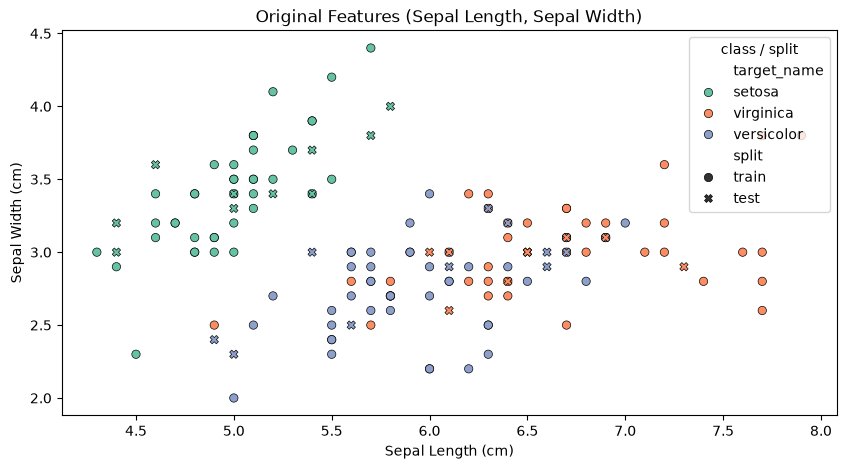

In [18]:
# 시각화 및 결과 확인용 DF 새로 생성
train_df = raw_X_train.copy()
train_df['target'] = y_train
train_df['target_name'] = train_df['target'].map(target_names)
train_df['split'] = 'train'

test_df = raw_X_test.copy()
test_df['target'] = y_test
test_df['target_name'] = test_df['target'].map(target_names)
test_df['split'] = 'test'

split_df = pd.concat([train_df, test_df])
display(split_df)

plt.figure(figsize=(10, 5))
sns.scatterplot(
    split_df,
    x='sepal length (cm)',
    y='sepal width (cm)',
    hue='target_name',
    style='split',
    palette='Set2',
    edgecolor='black'
)

plt.title('Original Features (Sepal Length, Sepal Width)')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend(title='class / split')
plt.show()

## 06. PCA/LDA 전 스케일링
PCA는 분산이 큰 방향을 찾고, KMeans/SVM처럼 거리와 위치를 보는 알고리즘도 스케일 영향을 크게 받음.
feature 단위나 값의 범위가 다르면 숫자 범위가 큰 feature가 결과를 과하게 지배할 수 있음.

In [19]:
scaler = StandardScaler()   # 평균 0, 표준편차 1
scaled_X_train = scaler.fit_transform(raw_X_train)
scaled_X_test = scaler.transform(raw_X_test)

## 07. PCA

PCA는 **Principal Component Analysis** 주성분 분석을 의미하는 단어로

여러 feature에 흩어져 있는 정보를 더 적은 수의 새 축으로 압축하는 대표적인 **비지도 차원축소 방법**이다.

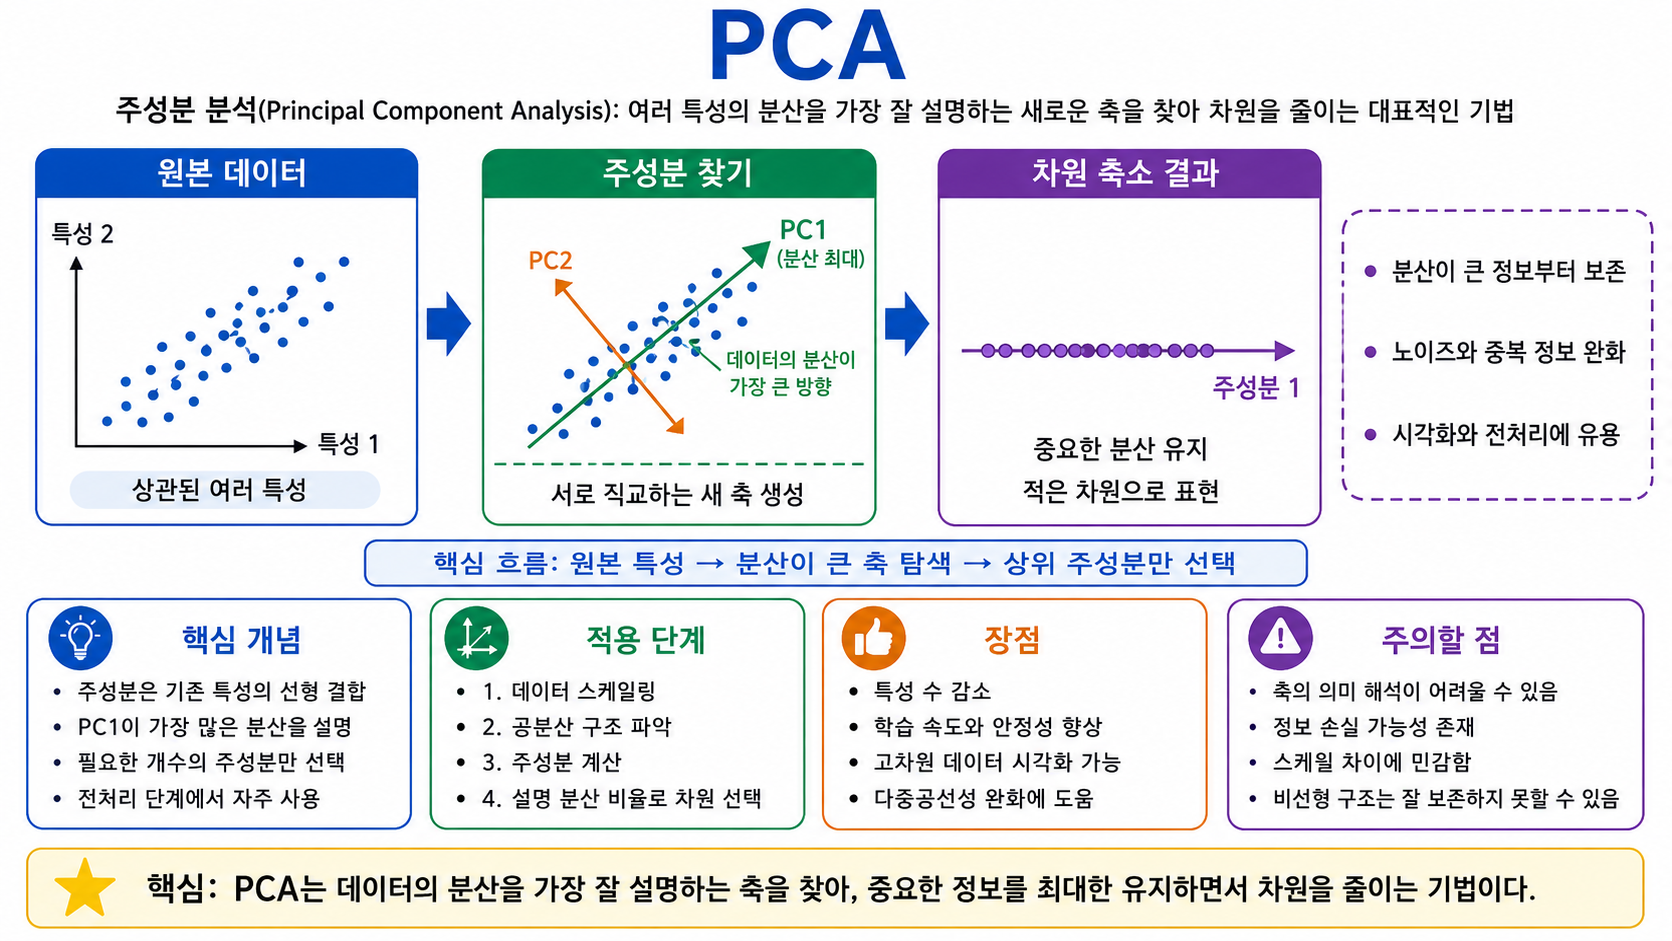

### 07-01. PCA가 하는 일

PCA는 원본 feature를 그대로 선택하지 않음.  
대신 원본 feature들을 조합해 데이터가 가장 많이 퍼져 있는 방향을 새 축으로 만듦.

- 첫 번째 새 축: `PC1`, Principal Component 1
- 두 번째 새 축: `PC2`, Principal Component 2

`PC1`은 원본 데이터의 변동을 가장 많이 설명하는 방향임.  
`PC2`는 `PC1`과 겹치지 않으면서 남은 변동을 가장 많이 설명하는 방향임.

---

### 07-02. PCA의 주요 단계:

1. **평균 중심화 (Mean Centering)**: 각 특성(feature)의 평균을 0으로 맞추기 위해 데이터를 평균 중심화한다.
   - 모든 특성의 평균을 0(원점)으로 맞추어 비교하기 쉽게 만든다.
   - 예: 원래 키 데이터가 [160, 170, 180]이면 평균(170)을 빼서 [−10, 0, 10]으로 만든다.
   $$
   X_{centered} = X - \text{mean}(X)
   $$

2. **공분산 행렬 계산 (Covariance Matrix Calculation)**: 각 특성 간의 상관관계를 나타내는 공분산 행렬을 계산한다.
   - **공분산(Covariance)** 이란?
      - 두 개의 확률변수 $X, Y$가 있을 때, 각 변수가 그들의 평균으로부터 얼마나 떨어져서(편차) 함께 움직이는지를 나타내는 값.
      - 공분산은 두 변수의 변동이 얼마나 연관되어 있는지를 나타내며, 양수일 경우 양의 상관관계, 음수일 경우 음의 상관관계를 나타낸다.
            -
   - **공분산 행렬** 이란?
      - 데이터에 존재하는 모든 변수 쌍에 대해 전부 계산해서 표(행렬)로 묶어놓은 것.
      - n차원 데이터가 어느 방향으로 길쭉하게 퍼져 있고, 어떤 변수들끼리 서로 연관관계가 형성되어 움직이는지 그 '형태'를 고스란히 담고 있는 요약본
            -
   $$
   \Sigma = \frac{1}{n-1} X_{centered}^T X_{centered}
   $$

3. **고유값 분해 (Eigen Decomposition)**: 위 공분산 행렬을 분해해서 **방향(고유벡터)** 과 **중요도(고유값)** 를 구한다.
   - 데이터가 가장 많이 퍼지는 방향과 그 방향의 중요도를 찾을 수 있다

   **고유벡터는 데이터의 새로운 축(Principal Components)을 나타내며, 고유값은 각 축의 중요도를 나타낸다.**

   - 고유벡터: 새로운 축 (Principal Component)
   - 고유값: 그 축이 설명하는 데이터의 분산(정보량)
   - 고유값 분해를 하는 이유는 데이터의 **변동성(분산)을 가장 잘 설명하는 새로운 축을 찾기 위해서이다.**

   - **고유벡터는 데이터의 새로운 좌표축을 제공**하며, **고유값은 해당 축의 중요도**를 나타낸다.
   - 데이터를 고유벡터들로 표현함으로써, 데이터를 새로운 좌표계(주성분 공간)로 변환하게 된다.
   $$
   \Sigma v_i = \lambda_i v_i
   $$

4. **주성분 선택 및 차원 축소**: 고유값이 큰 순서대로 k개의 주성분을 선택하고, 이를 기반으로 데이터를 변환한다.
   - 중요한 방향 몇 개만 남겨 차원을 줄인다.
   $$
   X_{reduced} = X_{centered} V_k
   $$
   ($V_k$ ==  k개의 주성분 벡터로 구성된 행렬)

```
즉, PCA의 핵심은 다음과 같다.

> 데이터의 중요한 퍼짐 방향을 찾아서, 원본 feature를 더 적은 수의 새 축으로 다시 표현하는 방법이다.
```

---

### 07-03. 설명 분산 비율

`explained_variance_ratio_`는 각 주성분이 원본 데이터의 변동을 얼마나 설명하는지 나타내는 비율이다.

예를 들어 다음과 같다면:

```text
PC1: 0.73
PC2: 0.23
```

해석은 다음과 같음.

- `PC1`이 원본 데이터 변동의 약 73%를 설명함.
- `PC2`가 원본 데이터 변동의 약 23%를 설명함.
- 두 주성분을 합치면 약 96% 정도의 변동을 설명함.

즉, 원본 feature 4개를 2개로 줄여도 데이터의 큰 구조는 대부분 유지된다고 볼 수 있음.

### 07-04. PCA 처리 과정과 코드 연결

1. `StandardScaler()`로 feature 범위를 맞춤.
2. `PCA(n_components=2)`로 2개의 새 축만 남기겠다고 설정함.
3. `fit_transform(scaled_X_train)`으로 train 데이터에서 주성분 방향을 찾고 train 데이터를 변환함.
4. `transform(scaled_X_test)`로 test 데이터도 같은 주성분 축에 올림.
5. `explained_variance_ratio_`로 `PC1`, `PC2`가 원본 변동을 얼마나 설명하는지 확인함.



In [20]:
# 원본 feature 정보를 주성분 2개로 압축
pca_model = PCA(n_components=2)

# fit_transform(): train 데이터에서 PCA 축을 학습 -> 새 축 2개로 변환
train_pca_2d = pca_model.fit_transform(scaled_X_train)

# transform: train 데이터 학습으로 얻은 2개의 축에 맞게 test 데이터 변환
test_pca_2d = pca_model.transform(scaled_X_test)

# PCA 결과를 DataFrame으로 정리함.
pca_train_df = pd.DataFrame(train_pca_2d, columns=['PC1', 'PC2'])
pca_train_df['target'] = y_train.to_numpy()
pca_train_df['target_name'] = pca_train_df['target'].map(target_names)
pca_train_df['split'] = 'train'

pca_test_df = pd.DataFrame(test_pca_2d, columns=['PC1', 'PC2'])
pca_test_df['target'] = y_test.to_numpy()
pca_test_df['target_name'] = pca_test_df['target'].map(target_names)
pca_test_df['split'] = 'test'

# 두 DataFrame을 합침
pca_result_df = pd.concat([pca_train_df, pca_test_df], ignore_index=True)


# explained_variance_ratio_: 각 주성분이 설명하는 분산 비율
explained_df = pd.DataFrame({
    'component': ['PC1', 'PC2'],
    'explained_variance_ratio': pca_model.explained_variance_ratio_,
    'cumulate_explained_ratio': np.cumsum(pca_model.explained_variance_ratio_)
})

display(pca_result_df.head().round(4))
display(explained_df.round(4))

,PC1,PC2,target,target_name,split
0,-2.3543,-1.0337,0,setosa,train
1,0.3281,-1.4846,2,virginica,train
2,1.2291,-0.0885,1,versicolor,train
3,-2.1945,-0.4145,0,setosa,train
4,0.2425,-1.2777,1,versicolor,train


,component,explained_variance_ratio,cumulate_explained_ratio
0,PC1,0.7268,0.7268
1,PC2,0.2307,0.9574


## 08. PCA 결과 시각화

PCA로 4개 feature를 2개 주성분으로 압축하면, 전체 feature 정보를 반영한 2차원 산점도를 그릴 수 있음.  
점 색은 실제 품종이고, 점 모양은 train/test 구분임.


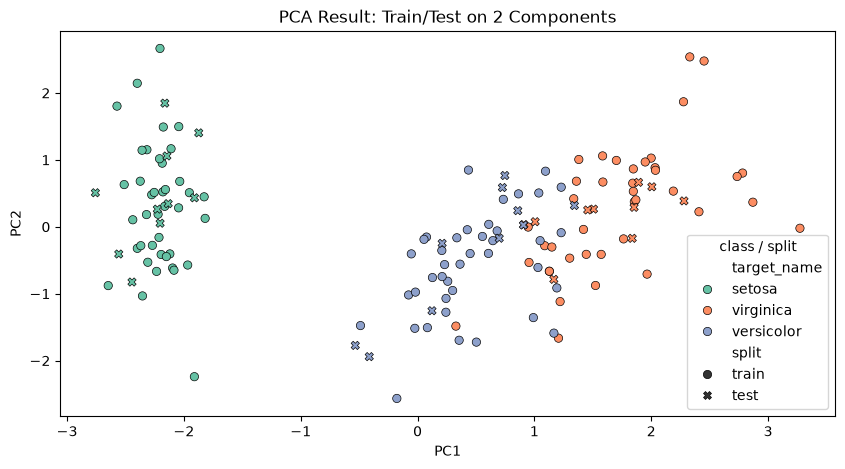

In [21]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=pca_result_df,
    x='PC1',
    y='PC2',
    hue='target_name',
    style='split',
    palette='Set2',
    edgecolor='black'
)

plt.title('PCA Result: Train/Test on 2 Components')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='class / split')
plt.show()

# PCA는 target(정답)을 보지 않았지만 품종별 분포가 어느 정도 나뉘는지
# 시각적으로 확인할 수 있다.

## 09. LDA

LDA는 **Linear Discriminant Analysis**, 즉 선형 판별 분석을 의미한다.

PCA처럼 차원을 줄일 수 있지만, PCA와 가장 큰 차이는 **target class를 사용한다는 점**이다.

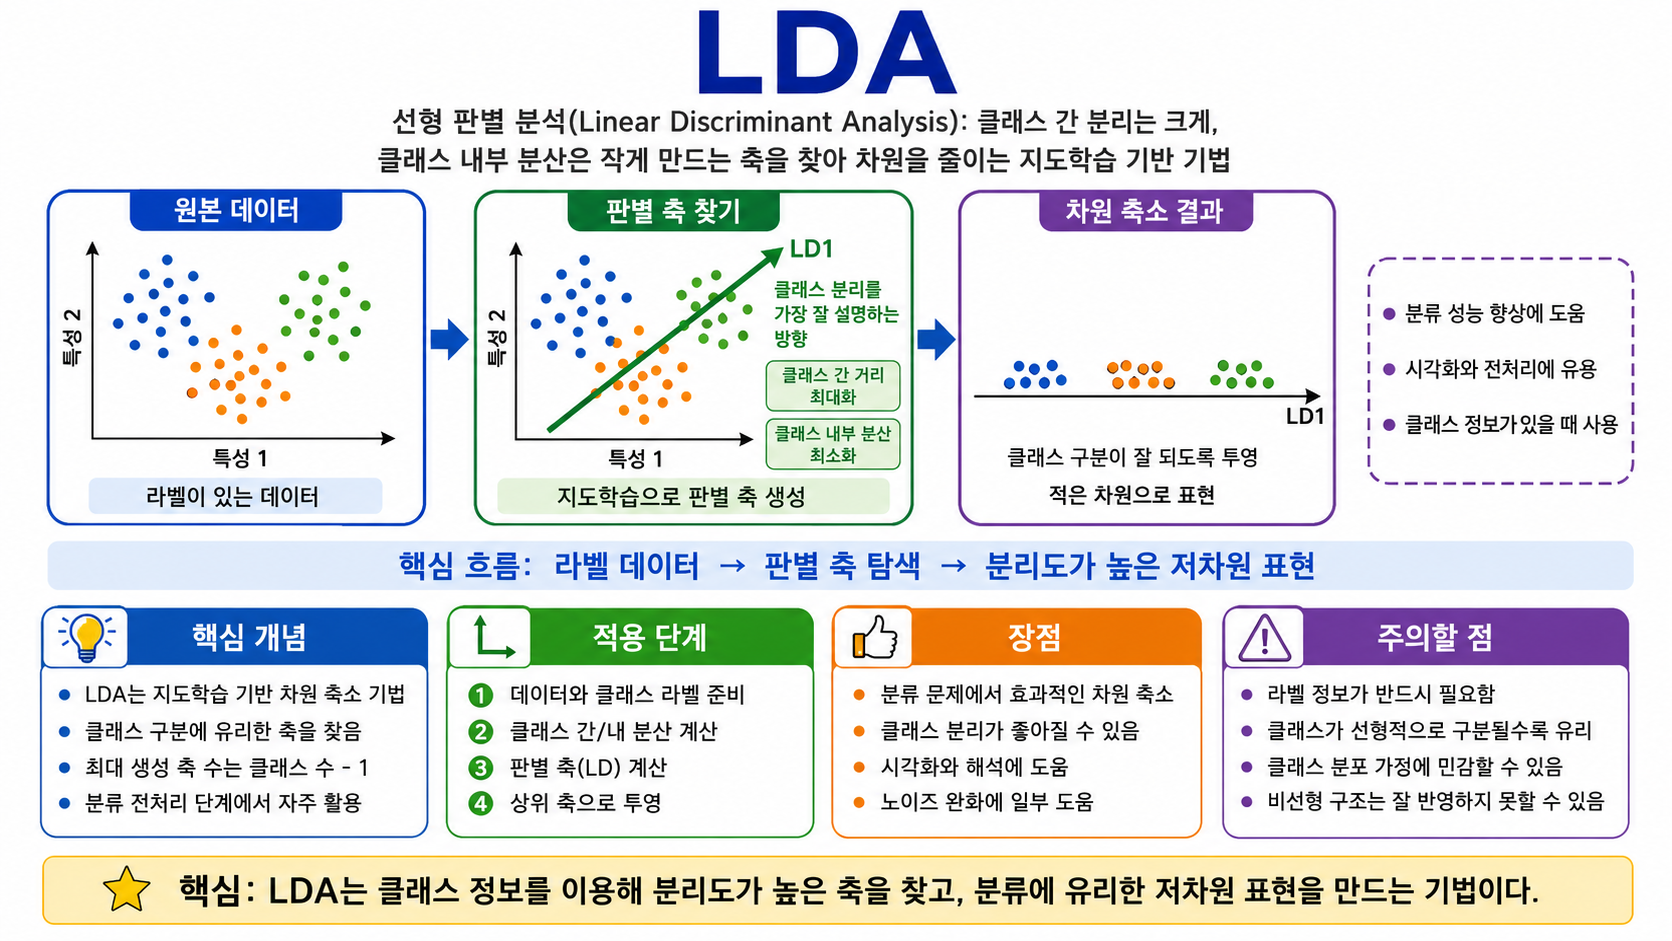

### 09-01. LDA를 왜 배우는가?

PCA는 target을 보지 않고 데이터가 많이 퍼진 방향을 찾음.  
그래서 분산은 잘 보존하지만, class가 잘 나뉘는 방향을 보장하지는 않음.

LDA는 분류 문제에서 class가 더 잘 구분되는 방향을 찾기 위해 사용함.

- PCA: 데이터가 많이 퍼진 방향을 찾음.
- LDA: class가 잘 나뉘는 방향을 찾음.

즉, LDA는 **분류 문제에서 시각화와 차원축소를 동시에 설명하기 좋은 방법** 이다.

---

### 09-02. LDA(Linear Discriminant Analysis) 처리 과정

LDA는 **클래스를 가장 잘 구분할 수 있는 직선 방향**을 찾는 것이 목적이다.

* **클래스 간 거리는 멀어지고**,
* **클래스 내부 데이터는 뭉치도록**
  하는 방향 벡터 **w**를 구하는 것이 핵심이다.

**1. 클래스별 평균 벡터 (클래스 중심점) 계산**

* 예를 들어 클래스가 두 개라고 하자: 클래스 1과 클래스 2
* 각 클래스의 평균 벡터 \$\mu\_1\$, \$\mu\_2\$는 다음처럼 계산한다:

$$
\mu_1 = \frac{1}{N_1} \sum_{x_i \in \text{class 1}} x_i \quad,\quad
\mu_2 = \frac{1}{N_2} \sum_{x_i \in \text{class 2}} x_i
$$

* 즉, 각 클래스의 데이터 포인트들의 평균값 (벡터 평균)

**2. 클래스 내 분산 (Within-class scatter matrix) 계산**

* 각 클래스의 내부 흩어짐(분산)을 먼저 계산한다.

$$
S_i = \sum_{x \in \text{class } i} (x - \mu_i)(x - \mu_i)^T
$$

* 이걸 두 클래스에 대해 각각 계산해서 더한다:

$$
S_W = S_1 + S_2
$$

* 즉, 전체 클래스 내부의 분산을 더한 값이 **Within-class scatter matrix**, \$S\_W\$이다.

> 이 값은 **작아야** 한다. → 투영했을 때 클래스 내부의 포인트들이 서로 가까워져야 하기 때문

**3. 클래스 간 분산 (Between-class scatter matrix) 계산**

* 두 클래스 중심점의 차이를 이용한다:

$$
S_B = (\mu_1 - \mu_2)(\mu_1 - \mu_2)^T
$$

* 이는 클래스 중심 간의 거리를 나타낸다.
* **클래스 간 차이는 커야 한다.**

> 이 값은 **커져야** 한다. → 투영했을 때 클래스끼리 서로 멀리 떨어져 있어야 함

**4. 최적의 방향 벡터 \$w\$ 계산**

* 목표는 아래의 식처럼 **Between-class scatter를 최대화**하고, **Within-class scatter를 최소화**하는 \$w\$를 찾는 것:

$$
w = S_W^{-1}(\mu_1 - \mu_2)
$$

* 직관적으로,

  * \$\mu\_1 - \mu\_2\$: 클래스 간의 중심 거리 방향
  * \$S\_W^{-1}\$: 클래스 내부 분산이 적은 쪽을 선호하도록 가중치 조절

---

### 09-03. LDA가 찾는 좋은 축
**1. class 사이 거리는 멀게**
- setosa, versicolor, virginica의 중심이 서로 멀어지는 방향을 선호함.
- class끼리 멀리 떨어질수록 구분하기 쉬움.

**2. 같은 class 내부는 가깝게**
- 같은 품종 데이터는 한쪽에 모이는 방향을 선호함.
- class 내부가 흩어져 있으면 분류가 어려워짐.

한 줄로 정리하면 다음과 같음.

> LDA는 class 간 거리는 크게 만들고, class 내부 흩어짐은 작게 만드는 방향을 찾는 방법임.

---

### 09-03. PCA와 LDA 비교

| 구분 | PCA | LDA |
|---|---|---|
| target 사용 | 사용하지 않음 | 사용함 |
| 학습 종류 | 비지도 차원축소 | 지도학습 기반 차원축소 |
| 찾는 방향 | 데이터 분산이 큰 방향 | class가 잘 구분되는 방향 |
| 주 사용 목적 | 구조 파악, 시각화, 압축 | class 분리 시각화, 분류 전처리 |
| target 없는 데이터 | 사용 가능 | 사용 불가 |

### 09-04. n_components 제한

LDA에서 만들 수 있는 축의 최대 개수는 다음 값보다 클 수 없다.

```text
min(class 개수 - 1, 원본 feature 개수)
```

Iris 데이터는 class가 3개이고 feature가 4개임.

```text
min(3 - 1, 4) = 2
```

그래서 Iris 데이터에서는 LDA로 최대 2차원까지 줄일 수 있음.



In [26]:
# class 정보를 이용해 2차원의 판별 축을 만든다.
lda_model = LinearDiscriminantAnalysis(n_components=2)

# LDA는 학습 시 target(정답 y)가 포함되어야 한다!
lda_train_2d = lda_model.fit_transform(scaled_X_train, y_train)
lda_test_2d = lda_model.transform(scaled_X_test)

lda_explained_df = pd.DataFrame({
    'component': ['LD1', 'LD2'],
    'explained_variance_ratio': lda_model.explained_variance_ratio_,
    'cumulative_explained_ratio': np.cumsum(lda_model.explained_variance_ratio_)
})

display(lda_explained_df.round(4))



,component,explained_variance_ratio,cumulative_explained_ratio
0,LD1,0.9904,0.9904
1,LD2,0.0096,1.0000


## 10. LDA 결과 시각화

LDA는 class 정보를 사용했기 때문에, 분류 문제의 class 구분을 보여주는 시각화에 적합함.  
PCA 결과와 비교하면서 어떤 방식이 class를 더 잘 나누어 보이게 하는지 확인함.


,LD1,LD2,target,target_name,split
0,6.675076,1.005258,0,setosa,train
1,-4.647101,0.666281,2,virginica,train
2,-2.376595,0.812628,1,versicolor,train
3,7.451128,0.907150,0,setosa,train
4,-1.863046,1.126570,1,versicolor,train


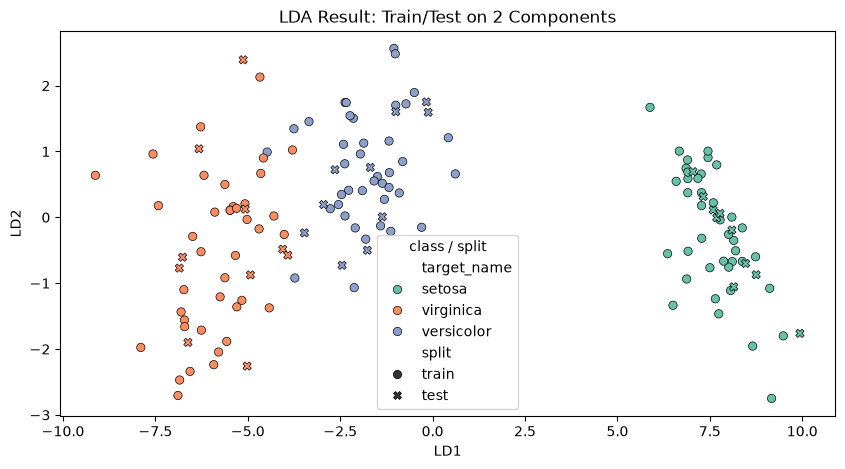

In [27]:
lda_train_df = pd.DataFrame(lda_train_2d, columns=['LD1', 'LD2'])
lda_train_df['target'] = y_train.to_numpy()
lda_train_df['target_name'] = lda_train_df['target'].map(target_names)
lda_train_df['split'] = 'train'

lda_test_df = pd.DataFrame(lda_test_2d, columns=['LD1', 'LD2'])
lda_test_df['target'] = y_test.to_numpy()
lda_test_df['target_name'] = lda_test_df['target'].map(target_names)
lda_test_df['split'] = 'test'

lda_result_df = pd.concat([lda_train_df, lda_test_df], ignore_index=True)

display(lda_result_df.head())

plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=lda_result_df,
    x='LD1',
    y='LD2',
    hue='target_name',
    style='split',
    palette='Set2',
    edgecolor='black'
)

plt.title('LDA Result: Train/Test on Class-aware 2D Projection')
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.legend(title='class / split')
plt.show()

## 11. 원본 feature, PCA feature, LDA feature로 모델 비교

차원축소가 시각화에만 쓰이는 것은 아니다.

원본 feature, PCA feature, LDA feature를 같은 모델에 넣어 평가하면 차원축소가 모델 성능에 어떤 영향을 주는지도 확인할 수 있다.

- feature 개수가 줄었는가?
- train/test accuracy가 크게 떨어지지 않았는가?
- train/test 차이가 과하게 커지지 않았는가?


In [28]:
# 원본 feature 모델: 4개 feature를 그대로 사용함.
raw_clf = RandomForestClassifier(random_state=42)
raw_clf.fit(raw_X_train, y_train)

# PCA feature 모델: train에서 학습한 PCA 2차원 feature를 사용함.
pca_clf = RandomForestClassifier(random_state=42)
pca_clf.fit(train_pca_2d, y_train)

# LDA feature 모델: train에서 학습한 LDA 2차원 feature를 사용함.
lda_clf = RandomForestClassifier(random_state=42)
lda_clf.fit(lda_train_2d, y_train)

comparison_df = pd.DataFrame([
    {
        'input_data': 'original_4_features',
        'feature_count': raw_X_train.shape[1],
        'train_accuracy': raw_clf.score(raw_X_train, y_train),
        'test_accuracy': raw_clf.score(raw_X_test, y_test),
    },
    {
        'input_data': 'pca_2_components',
        'feature_count': train_pca_2d.shape[1],
        'train_accuracy': pca_clf.score(train_pca_2d, y_train),
        'test_accuracy': pca_clf.score(test_pca_2d, y_test),
    },
    {
        'input_data': 'lda_2_components',
        'feature_count': lda_train_2d.shape[1],
        'train_accuracy': lda_clf.score(lda_train_2d, y_train),
        'test_accuracy': lda_clf.score(lda_test_2d, y_test),
    }
])

comparison_df['train_test_gap'] = comparison_df['train_accuracy'] - comparison_df['test_accuracy']
display(comparison_df)

# 원본과 PCA, LDA를 비교했을 때 test_accuracy가 비슷하거나 높을 경우
# 차원 축소가 예측에 도움이 되었다고 생각할 수 있다.
# 그리고, 차원 수가 적으면서 test_accuracy가 높은 모델이 더 좋다고 판단할 수 있다.

,input_data,feature_count,train_accuracy,test_accuracy,train_test_gap
0,original_4_features,4,1.0,0.9,0.1
1,pca_2_components,2,1.0,0.9,0.1
2,lda_2_components,2,1.0,1.0,0.0


## 12. 수업 마무리 정리

- PCA는 target 없이 원본 feature의 분산을 잘 보존하는 새 축을 찾음.
- LDA는 target class를 사용해 class가 잘 나뉘는 새 축을 찾음.
- PCA는 비지도 차원축소이고, LDA는 지도학습 기반 차원축소임.
- 모델 평가 흐름에서는 train/test를 먼저 나누고, 스케일러와 차원축소 모델은 train에만 `fit`함.
- test 데이터에는 train에서 배운 기준으로 `transform`만 적용해 데이터 누수를 막음.
- PCA/LDA 결과는 2차원 시각화에 유용하지만, 축 이름이 원본 feature와 달라 해석이 어려울 수 있음.
- LDA는 class 분리에 강하지만 target이 없는 데이터에는 사용할 수 없다는 한계가 있음.
- 차원축소는 다음 비지도 학습에서 군집 결과를 시각화하는 도구로도 자주 사용함.
